# Ev Fiyatlarını Makine Öğrenmesi ile Tahmin Etmek: Uçtan Uca Bir Regresyon Projesi
Türkiye Yapay Zeka Akademisi — Uçtan Uca Makine Öğrenmesi Projesi Final Ödevi

In [1]:
"""
PROJE: Ev Fiyatlarını Makine Öğrenmesi ile Tahmin Etmek (Uçtan Uca Regresyon Projesi)

AMAÇ:
    Kaliforniya'daki mahallelere ait demografik ve coğrafi özelliklerden yola
    çıkarak bölgedeki evlerin medyan fiyatını (median_house_value) tahmin
    etmek. Problem türü: REGRESYON.

KULLANILAN KÜTÜPHANELER:
    - pandas, numpy      : veri okuma / işleme
    - matplotlib, seaborn : görselleştirme
    - scikit-learn        : ön işleme, modelleme, değerlendirme

ÇALIŞTIRMA ADIMLARI:
    1. Bu notebook'taki tüm hücreleri sırasıyla (yukarıdan aşağıya) çalıştırın.
    2. İnternet bağlantısı gereklidir; veri seti kod içinde otomatik olarak
       aşağıdaki adresten indirilir, ekstra bir dosya indirmenize gerek yoktur:
       https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv
    3. Notebook baştan sona hatasız çalışacak şekilde hazırlanmıştır, hiçbir
       hücrede elle tamamlama (TODO) gerekmez.
"""
print("Proje docstring'i yukarıda tanımlanmıştır. Notebook çalıştırılmaya hazır.")


Proje docstring'i yukarıda tanımlanmıştır. Notebook çalıştırılmaya hazır.


## 2. Kütüphanelerin Import Edilmesi

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Kütüphaneler başarıyla yüklendi.")


Kütüphaneler başarıyla yüklendi.


## 3. Veri Setinin Yüklenmesi
**Veri seti:** California Housing Prices (1990 ABD nüfus sayımı verilerinden türetilmiştir).

**Kaynak:** Veri seti, Aurélien Géron'un *Hands-On Machine Learning* kitabının resmi GitHub deposunda barındırılmaktadır ve `pandas.read_csv` ile doğrudan bir URL üzerinden otomatik olarak indirilir; ek bir dosya indirip proje klasörüne koymanıza gerek yoktur:
`https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv`

**Neyi temsil ediyor:** Her satır, Kaliforniya'daki bir mahalleyi (census block group) temsil eder. Sütunlar konum, demografi (nüfus, hane sayısı, medyan gelir) ve konut özellikleri (oda sayısı, yaş vb.) içerir.

**Hedef değişken:** Veri setinde hazır bir `price` sütunu bulunmamaktadır; bunun yerine gerçek hedef sütun **`median_house_value`** olup mahalledeki evlerin medyan (ortanca) satış fiyatını (USD) temsil eder. Bu proje boyunca hedef değişken olarak `median_house_value` kullanılacaktır.

**Satır sayısı:** 20.640 satır

In [3]:
DATA_URL = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
TARGET_COL = "median_house_value"

df = pd.read_csv(DATA_URL)

print(f"Veri seti başarıyla indirildi. Boyut: {df.shape[0]} satır, {df.shape[1]} sütun.")
df.head()


Veri seti başarıyla indirildi. Boyut: 20640 satır, 10 sütun.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 4. Problem Türü

In [4]:
print("PROBLEM TÜRÜ: REGRESYON")
print(f"HEDEF DEĞİŞKEN: '{TARGET_COL}' (mahalledeki evlerin medyan satış fiyatı, USD)")
print(f"Hedef değişken veri tipi: {df[TARGET_COL].dtype}")
print(f"Hedef değişken istatistikleri:\n{df[TARGET_COL].describe()}")


PROBLEM TÜRÜ: REGRESYON
HEDEF DEĞİŞKEN: 'median_house_value' (mahalledeki evlerin medyan satış fiyatı, USD)
Hedef değişken veri tipi: float64
Hedef değişken istatistikleri:
count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64


## 5. Temel Veri İncelemesi

In [5]:
print("=== head() ===")
display(df.head())

print("\n=== shape ===")
print(df.shape)

print("\n=== info() ===")
df.info()

print("\n=== describe() ===")
display(df.describe())


=== head() ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



=== shape ===
(20640, 10)

=== info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

=== describe() ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
# Kategorik ve sayısal sütunların belirlenmesi
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Kategorik sütunlar ({len(categorical_cols)}): {categorical_cols}")
print(f"Sayısal sütunlar ({len(numerical_cols)}): {numerical_cols}")

print("\nKategorik sütunun benzersiz değerleri:")
for col in categorical_cols:
    print(f"  {col}: {df[col].unique()}")


Kategorik sütunlar (1): ['ocean_proximity']
Sayısal sütunlar (9): ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

Kategorik sütunun benzersiz değerleri:
  ocean_proximity: ['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


## 6. Eksik Değer Analizi

In [7]:
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]

if len(missing_cols) > 0:
    print("Eksik değer bulunan sütunlar:")
    missing_summary = pd.DataFrame({
        "Eksik Değer Sayısı": missing_cols,
        "Oran (%)": (missing_cols / len(df) * 100).round(2)
    })
    display(missing_summary)
else:
    print("Veri setinde eksik değer bulunmamaktadır.")


Eksik değer bulunan sütunlar:


,Eksik Değer Sayısı,Oran (%)
total_bedrooms,207,1.0


## 7. Veri Temizleme (Eksik Değerlerin Doldurulması)
`total_bedrooms` sütunundaki eksik değerler, aykırı değerlerden fazla etkilenmemesi için medyan ile doldurulmuştur.

In [8]:
bedrooms_median = df["total_bedrooms"].median()
df["total_bedrooms"] = df["total_bedrooms"].fillna(bedrooms_median)

print(f"'total_bedrooms' sütunundaki eksik değerler medyan ({bedrooms_median:.2f}) ile dolduruldu.")
print(f"Doldurma sonrası toplam eksik değer sayısı: {df.isnull().sum().sum()}")


'total_bedrooms' sütunundaki eksik değerler medyan (435.00) ile dolduruldu.
Doldurma sonrası toplam eksik değer sayısı: 0


## 8. Aykırı Değer Analizi

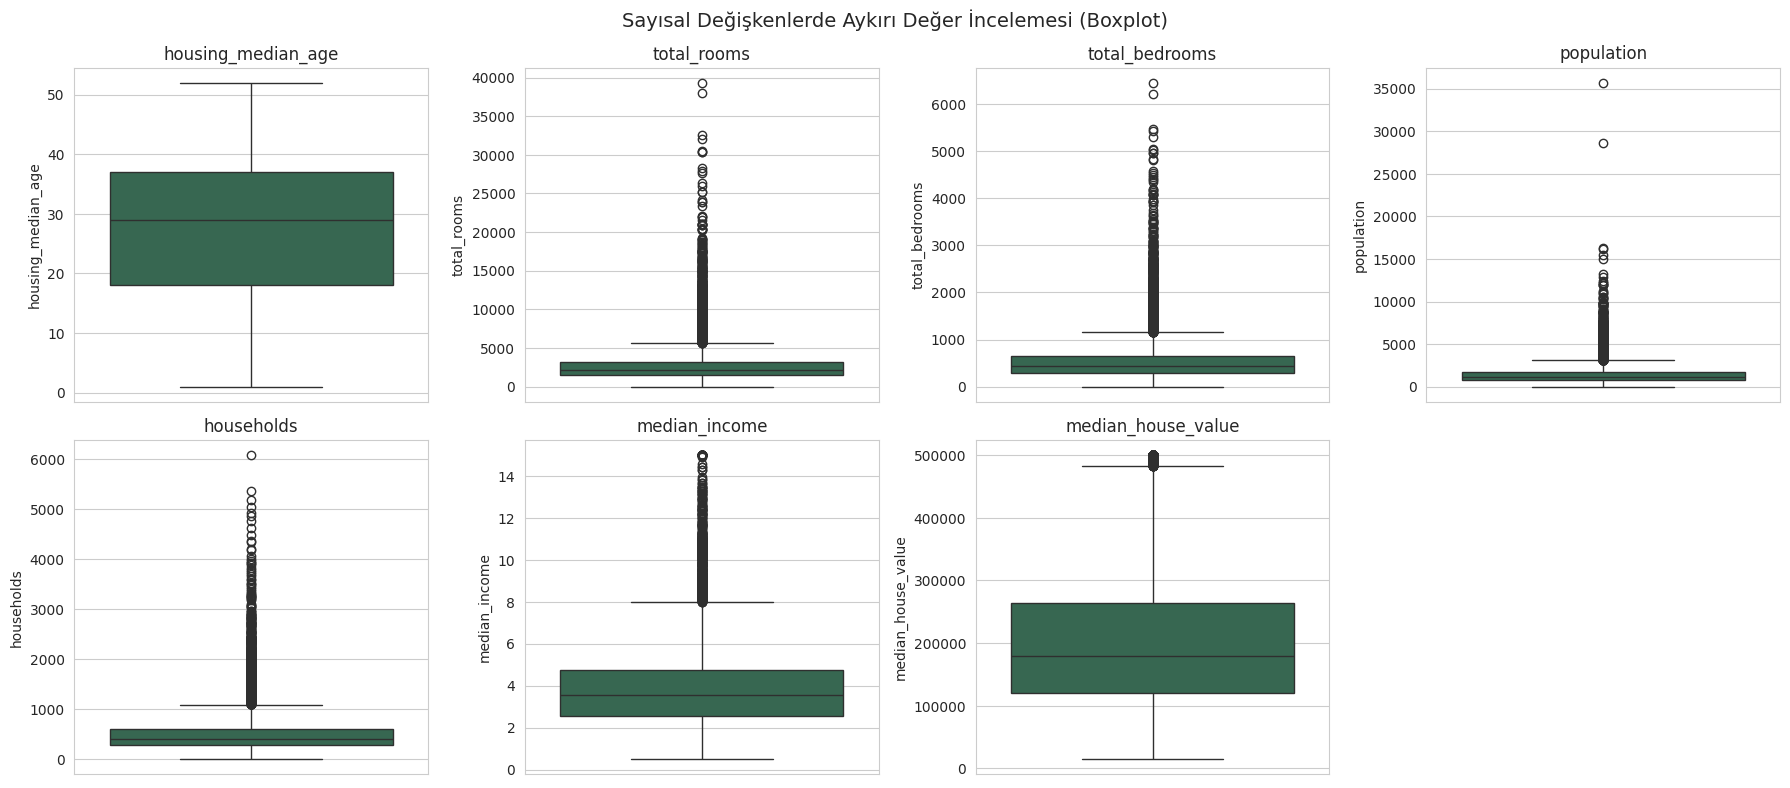

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
outlier_check_cols = ["housing_median_age", "total_rooms", "total_bedrooms",
                       "population", "households", "median_income", TARGET_COL]

for ax, col in zip(axes.ravel(), outlier_check_cols):
    sns.boxplot(y=df[col], ax=ax, color="#2F6F52")
    ax.set_title(col)

axes.ravel()[-1].axis("off")
plt.suptitle("Sayısal Değişkenlerde Aykırı Değer İncelemesi (Boxplot)", fontsize=14)
plt.tight_layout()
plt.show()


In [10]:
# IQR yöntemiyle aykırı değer oranlarının incelenmesi
def iqr_outlier_ratio(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), round(len(outliers) / len(series) * 100, 2)

print("IQR yöntemine göre aykırı değer oranları:")
for col in outlier_check_cols:
    count, pct = iqr_outlier_ratio(df[col])
    print(f"  {col}: {count} adet (%{pct})")

# Aykırı değerler otomatik olarak silinmemiştir. Örneğin median_income ve
# total_rooms gibi sütunlardaki yüksek değerler gerçek dünyada var olan, anlamlı
# mahalleleri temsil edebilir (örn. çok yüksek gelirli ya da çok kalabalık bölgeler).
# Bu satırları silmek, modelin öğrenebileceği gerçek örüntüleri kaybetmesine yol
# açabilir. Bunun yerine, sadece hedef değişkende (median_house_value) veri
# toplama sürecinden kaynaklanan bir üst sınır (cap) sorunu olup olmadığı kontrol edilir.
capped_count = (df[TARGET_COL] == df[TARGET_COL].max()).sum()
print(f"\nHedef değişkenin maksimum değerine ({df[TARGET_COL].max()}) eşit satır sayısı: {capped_count}")
print("Bu satırlar, veri toplama sırasında oluşmuş bir üst sınır (cap) etkisi taşıyabileceğinden çıkarılmıştır.")

df = df[df[TARGET_COL] < df[TARGET_COL].max()].reset_index(drop=True)
print(f"Temizleme sonrası veri seti boyutu: {df.shape}")


IQR yöntemine göre aykırı değer oranları:
  housing_median_age: 0 adet (%0.0)
  total_rooms: 1287 adet (%6.24)
  total_bedrooms: 1306 adet (%6.33)
  population: 1196 adet (%5.79)
  households: 1220 adet (%5.91)
  median_income: 681 adet (%3.3)
  median_house_value: 1071 adet (%5.19)

Hedef değişkenin maksimum değerine (500001.0) eşit satır sayısı: 965
Bu satırlar, veri toplama sırasında oluşmuş bir üst sınır (cap) etkisi taşıyabileceğinden çıkarılmıştır.
Temizleme sonrası veri seti boyutu: (19675, 10)


## 9. Feature Engineering (En Az 2 Yeni Öznitelik)
Veri setinin gerçek sütunları (`total_rooms`, `total_bedrooms`, `population`, `households`) incelenerek aşağıdaki iki yeni ve anlamlı öznitelik oluşturulmuştur:

- **rooms_per_household**: Bir hanedeki ortalama oda sayısı (`total_rooms / households`). Mahallenin konut büyüklüğü/refah seviyesi hakkında `total_rooms` tek başına verdiğinden daha anlamlı bilgi verir.
- **bedrooms_per_room**: Toplam odalar içindeki yatak odası oranı (`total_bedrooms / total_rooms`). Düşük oran genellikle daha büyük/lüks evleri işaret eder ve fiyatla ilişkilidir.
- **population_per_household**: Bir hanedeki ortalama kişi sayısı (`population / households`). Hane yoğunluğunu ölçer, kalabalık/aile büyüklüğü ile fiyat arasındaki ilişkiyi yakalamaya yardımcı olur.

In [11]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

new_features = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]
print("Oluşturulan yeni öznitelikler:")
display(df[new_features].describe())


Oluşturulan yeni öznitelikler:


,rooms_per_household,bedrooms_per_room,population_per_household
count,19675.000000,19675.000000,19675.000000
mean,5.360901,0.215757,3.095189
std,2.292538,0.064628,10.631977
min,0.846154,0.037151,0.692308
25%,4.414568,0.177480,2.445486
50%,5.184322,0.204580,2.837134
75%,5.970677,0.241304,3.304894
max,132.533333,2.824675,1243.333333


## 10. Kategorik Değişkenlerin Encoding İşlemi
`ocean_proximity` kategorik sütunu `OneHotEncoder` ile sayısal forma dönüştürülmüştür.

In [12]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ocean_encoded = ohe.fit_transform(df[["ocean_proximity"]])
ocean_encoded_cols = ohe.get_feature_names_out(["ocean_proximity"])

ocean_df = pd.DataFrame(ocean_encoded, columns=ocean_encoded_cols, index=df.index)
df_encoded = pd.concat([df.drop(columns=["ocean_proximity"]), ocean_df], axis=1)

print("Encoding sonrası oluşan yeni sütunlar:", list(ocean_encoded_cols))
df_encoded.head()


Encoding sonrası oluşan yeni sütunlar: ['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,0.0,0.0,0.0,1.0,0.0


## 11. Train / Validation / Test Ayrımı
**Veri sızıntısını (data leakage) önlemek için** train/validation/test ayrımı, korelasyon tabanlı feature selection adımından önce yapılmıştır: bu sayede feature seçimi yalnızca training verisine bakılarak yapılacak, validation ve test verisindeki hiçbir bilgi seçim kararını etkilemeyecektir.

Veri seti %70 training, %15 validation, %15 test olacak şekilde ayrılmıştır. `random_state=42` ile tekrarlanabilirlik sağlanmıştır. Test verisi, notebook boyunca yalnızca final değerlendirme için kullanılacaktır.

In [13]:
# Ham (henüz feature selection uygulanmamış) X ve y
X_full = df_encoded.drop(columns=[TARGET_COL])
y_full = df_encoded[TARGET_COL]

X_train_full, X_temp_full, y_train, y_temp = train_test_split(
    X_full, y_full, test_size=0.30, random_state=RANDOM_STATE
)
X_val_full, X_test_full, y_val, y_test = train_test_split(
    X_temp_full, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(f"Training set:   {X_train_full.shape[0]} satır (%{X_train_full.shape[0]/len(X_full)*100:.1f})")
print(f"Validation set: {X_val_full.shape[0]} satır (%{X_val_full.shape[0]/len(X_full)*100:.1f})")
print(f"Test set:       {X_test_full.shape[0]} satır (%{X_test_full.shape[0]/len(X_full)*100:.1f})")


Training set:   13772 satır (%70.0)
Validation set: 2951 satır (%15.0)
Test set:       2952 satır (%15.0)


## 12. Feature Selection (Öznitelik Seçimi)
Öznitelik seçimi için **korelasyon analizi** kullanılmıştır. Veri sızıntısını önlemek için korelasyon katsayıları **yalnızca training verisi (`X_train_full`, `y_train`) üzerinden** hesaplanmış, validation ve test verisi bu hesaplamaya hiç dahil edilmemiştir. Her özniteliğin hedef değişkenle Pearson korelasyon katsayısının mutlak değeri hesaplanmış, |korelasyon| < 0.05 olan (hedefle neredeyse hiç ilişkisi olmayan) öznitelikler elenmiştir. Seçilen sütunlar daha sonra validation ve test setlerine de (yeniden hesaplama yapılmadan) aynen uygulanmıştır.

Özniteliklerin hedef değişkenle korelasyonu — SADECE training verisi üzerinden (mutlak değer, büyükten küçüğe):


,median_house_value
median_income,0.641574
ocean_proximity_INLAND,0.500094
ocean_proximity_<1H OCEAN,0.285524
bedrooms_per_room,0.201966
latitude,0.151677
ocean_proximity_NEAR BAY,0.149939
total_rooms,0.144176
ocean_proximity_NEAR OCEAN,0.142289
rooms_per_household,0.102367
households,0.096422



Seçilen öznitelikler (12): ['median_income', 'ocean_proximity_INLAND', 'ocean_proximity_<1H OCEAN', 'bedrooms_per_room', 'latitude', 'ocean_proximity_NEAR BAY', 'total_rooms', 'ocean_proximity_NEAR OCEAN', 'rooms_per_household', 'households', 'total_bedrooms', 'housing_median_age']
Elenen öznitelikler (4): ['longitude', 'ocean_proximity_ISLAND', 'population_per_household', 'population']


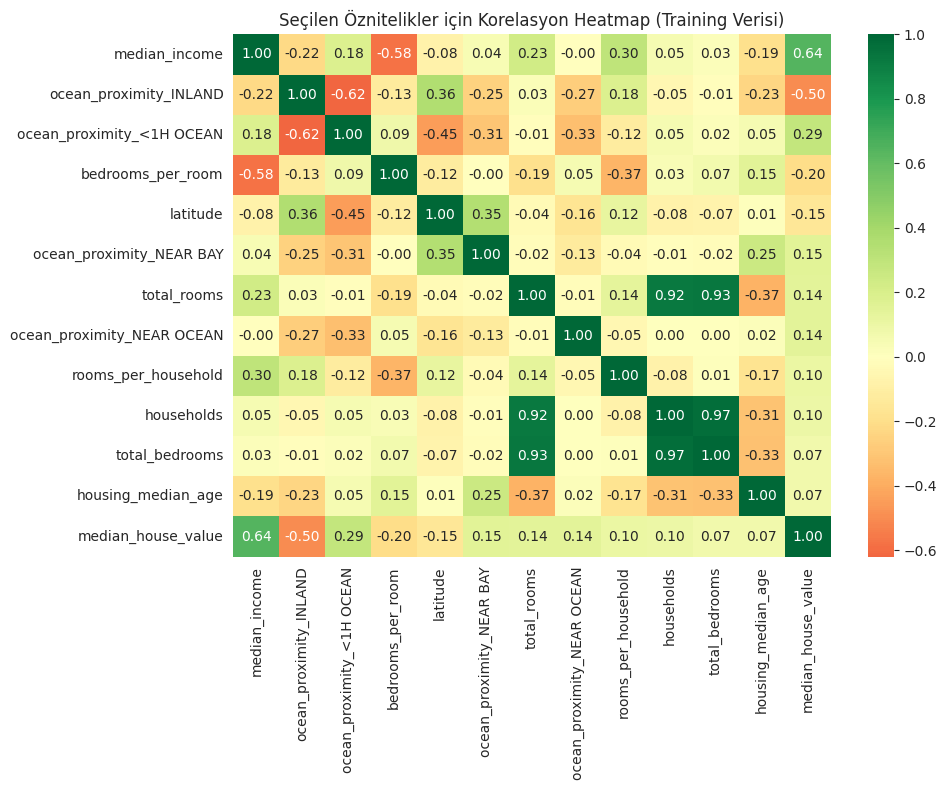


Modelleme için nihai öznitelik matrisi boyutu (train): (13772, 12)


In [14]:
train_with_target = X_train_full.copy()
train_with_target[TARGET_COL] = y_train

corr_with_target = train_with_target.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL)
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

print("Özniteliklerin hedef değişkenle korelasyonu — SADECE training verisi üzerinden (mutlak değer, büyükten küçüğe):")
display(corr_sorted)

CORR_THRESHOLD = 0.05
selected_features = corr_sorted[corr_sorted >= CORR_THRESHOLD].index.tolist()
dropped_features = corr_sorted[corr_sorted < CORR_THRESHOLD].index.tolist()

print(f"\nSeçilen öznitelikler ({len(selected_features)}): {selected_features}")
print(f"Elenen öznitelikler ({len(dropped_features)}): {dropped_features}")

plt.figure(figsize=(10, 8))
sns.heatmap(train_with_target[selected_features + [TARGET_COL]].corr(), annot=True, fmt=".2f",
            cmap="RdYlGn", center=0)
plt.title("Seçilen Öznitelikler için Korelasyon Heatmap (Training Verisi)")
plt.tight_layout()
plt.show()

# Seçilen öznitelikler, hesaplama yapılmadan train/val/test setlerine uygulanır
X_train = X_train_full[selected_features]
X_val = X_val_full[selected_features]
X_test = X_test_full[selected_features]

print(f"\nModelleme için nihai öznitelik matrisi boyutu (train): {X_train.shape}")


## 13. Ölçekleme (Scaling)
Linear Regression ve Ridge Regression gibi mesafe/katsayı tabanlı modeller için `StandardScaler` uygulanmıştır. **Random Forest gibi tree-based (ağaç tabanlı) modeller için ölçekleme gerekli değildir**, çünkü bu modeller özniteliklerin mutlak büyüklüğüne değil, bölme (split) noktalarına dayanır. Veri sızıntısını önlemek için `scaler` **yalnızca training verisi üzerinde `fit` edilmiş**, ardından validation ve test verilerine sadece `transform` uygulanmıştır.

In [15]:
scaler = StandardScaler()
scaler.fit(X_train)  # yalnızca training verisi üzerinde fit edilir

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Ölçekleme tamamlandı. (Linear Regression ve Ridge için ölçekli veri; Random Forest için ölçeksiz veri kullanılacaktır.)")
X_train_scaled.head()


Ölçekleme tamamlandı. (Linear Regression ve Ridge için ölçekli veri; Random Forest için ölçeksiz veri kullanılacaktır.)


,median_income,ocean_proximity_INLAND,ocean_proximity_<1H OCEAN,bedrooms_per_room,latitude,ocean_proximity_NEAR BAY,total_rooms,ocean_proximity_NEAR OCEAN,rooms_per_household,households,total_bedrooms,housing_median_age
3438,0.790434,-0.706337,1.140652,-0.341555,-0.625823,-0.348828,0.020886,-0.375892,-0.103457,0.051003,-0.049896,-1.226788
18539,-0.576222,1.415755,-0.876692,-0.124610,0.930039,-0.348828,-0.543261,-0.375892,-0.254189,-0.522711,-0.574510,0.366765
16579,-0.013301,-0.706337,1.140652,0.057258,-0.337873,-0.348828,-0.715117,-0.375892,-0.414301,-0.677274,-0.731894,-0.190979
14811,-0.458022,-0.706337,-0.876692,0.615637,-1.150636,-0.348828,-0.126681,2.660342,-0.437497,0.113876,0.133719,-1.943887
4216,-1.078636,-0.706337,1.140652,3.197556,-0.732644,-0.348828,-0.484142,-0.375892,-1.125570,0.250101,0.260103,-0.031623


## 14. Model Eğitimi (En Az 3 Model)
Üç farklı regresyon modeli eğitilmiştir: **Linear Regression**, **Ridge Regression** ve **Random Forest Regressor**.

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

# Doğrusal modeller ölçekli veri, Random Forest ölçeksiz (orijinal) veri ile eğitilir
uses_scaled_data = {"Linear Regression": True, "Ridge": True, "Random Forest": False}

trained_models = {}
for name, model in models.items():
    X_tr = X_train_scaled if uses_scaled_data[name] else X_train
    model.fit(X_tr, y_train)
    trained_models[name] = model
    print(f"{name} eğitildi.")


Linear Regression eğitildi.
Ridge eğitildi.
Random Forest eğitildi.


## 15. Validation Setinde Model Karşılaştırması

In [17]:
def evaluate(model, X_eval, y_true):
    preds = model.predict(X_eval)
    mae = mean_absolute_error(y_true, preds)
    mse = mean_squared_error(y_true, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, preds)
    return mae, mse, rmse, r2

val_results = []
for name, model in trained_models.items():
    X_ev = X_val_scaled if uses_scaled_data[name] else X_val
    mae, mse, rmse, r2 = evaluate(model, X_ev, y_val)
    val_results.append({"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2})

val_results_df = pd.DataFrame(val_results).set_index("Model")
print("=== Validation Model Karşılaştırması ===")
display(val_results_df.round(2))

best_model_name = val_results_df["R2"].idxmax()
print(f"\nEn başarılı model (validation R² skoruna göre): {best_model_name}")


=== Validation Model Karşılaştırması ===


,MAE,MSE,RMSE,R2
Model,,,,
Linear Regression,47399.98,4.134530e+09,64300.31,0.58
Ridge,47391.73,4.132965e+09,64288.14,0.58
Random Forest,38418.87,3.003055e+09,54800.13,0.70



En başarılı model (validation R² skoruna göre): Random Forest


## 16. Cross-Validation

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("=== 5-Fold Cross-Validation Sonuçları (RMSE) ===")
cv_results = {}
for name, model in models.items():
    X_cv = X_train_scaled if uses_scaled_data[name] else X_train
    neg_mse_scores = cross_val_score(model, X_cv, y_train, cv=kf,
                                      scoring="neg_mean_squared_error", n_jobs=-1)
    rmse_scores = np.sqrt(-neg_mse_scores)
    cv_results[name] = (rmse_scores.mean(), rmse_scores.std())
    print(f"{name}: Ortalama RMSE = {rmse_scores.mean():.2f}  |  Std = {rmse_scores.std():.2f}")


=== 5-Fold Cross-Validation Sonuçları (RMSE) ===
Linear Regression: Ortalama RMSE = 62808.01  |  Std = 1712.56
Ridge: Ortalama RMSE = 62813.70  |  Std = 1729.02
Random Forest: Ortalama RMSE = 54944.51  |  Std = 1681.62


## 17. Hyperparameter Tuning
En başarılı model için `GridSearchCV` kullanılarak makul boyutlu bir hiperparametre araması yapılmıştır.

In [19]:
param_grids = {
    "Ridge": {"alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]},
    "Random Forest": {
        "n_estimators": [100],
        "max_depth": [10, None],
        "min_samples_leaf": [1, 2],
    },
}

X_train_for_best = X_train_scaled if uses_scaled_data[best_model_name] else X_train

if best_model_name == "Linear Regression":
    print("Linear Regression'ın ayarlanacak bir hiperparametresi bulunmamaktadır "
          "(kapalı-form çözüm kullanır). Bu nedenle GridSearchCV atlanmış, model "
          "olduğu gibi final model olarak kullanılacaktır.")
    best_model = trained_models["Linear Regression"]
    best_params = {}
    best_cv_score = cv_results["Linear Regression"][0]
else:
    base_model = models[best_model_name]
    grid = GridSearchCV(
        base_model,
        param_grid=param_grids[best_model_name],
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    grid.fit(X_train_for_best, y_train)
    best_model = grid.best_estimator_
    best_params = grid.best_params_
    best_cv_score = np.sqrt(-grid.best_score_)

print(f"\nEn iyi model: {best_model_name}")
print(f"En iyi parametreler (best_params_): {best_params}")
print(f"En iyi CV RMSE skoru (best_score_'dan hesaplanan): {best_cv_score:.2f}")



En iyi model: Random Forest
En iyi parametreler (best_params_): {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
En iyi CV RMSE skoru (best_score_'dan hesaplanan): 54742.67


## 18. Final Test Değerlendirmesi
Hyperparameter tuning sonrası elde edilen en iyi model, notebook boyunca hiç kullanılmamış olan **test verisi** üzerinde değerlendirilmiştir.

In [20]:
X_test_for_best = X_test_scaled if uses_scaled_data[best_model_name] else X_test

test_mae, test_mse, test_rmse, test_r2 = evaluate(best_model, X_test_for_best, y_test)

print("=== Final Test Sonuçları ===")
print(f"MAE  : {test_mae:.2f}")
print(f"MSE  : {test_mse:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"R2   : {test_r2:.4f}")

test_predictions = best_model.predict(X_test_for_best)
comparison_df = pd.DataFrame({
    "Gerçek Fiyat": y_test.values,
    "Tahmin Edilen Fiyat": test_predictions
}).reset_index(drop=True)

print("\nGerçek ve tahmin edilen fiyatlardan örnek satırlar:")
display(comparison_df.head(10))


=== Final Test Sonuçları ===
MAE  : 38740.33
MSE  : 3039053211.81
RMSE : 55127.61
R2   : 0.6895

Gerçek ve tahmin edilen fiyatlardan örnek satırlar:


,Gerçek Fiyat,Tahmin Edilen Fiyat
0,88000.0,130658.897619
1,152400.0,205319.555952
2,84200.0,108543.316667
3,127900.0,193429.500000
4,190700.0,137590.275397
5,394100.0,363431.860714
6,196600.0,259545.950000
7,177900.0,216948.792857
8,109800.0,115269.230159
9,216900.0,145643.198810


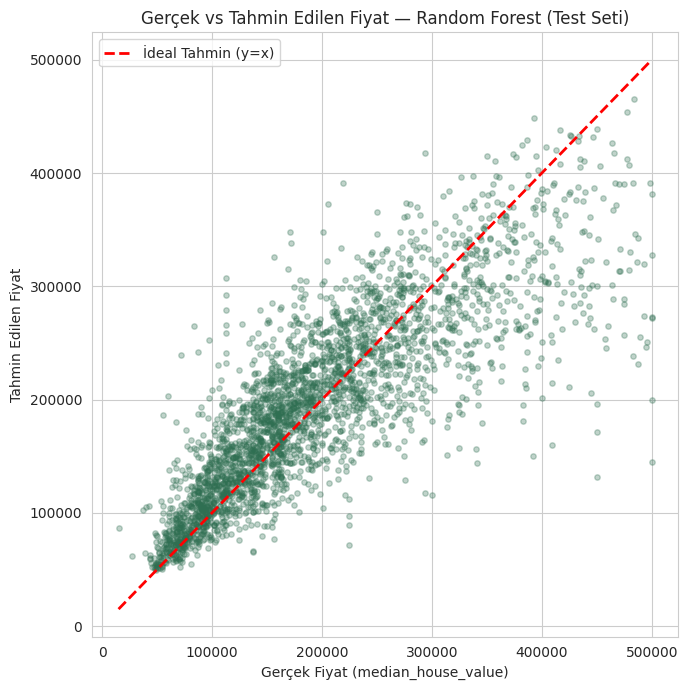

In [21]:
plt.figure(figsize=(7, 7))
plt.scatter(comparison_df["Gerçek Fiyat"], comparison_df["Tahmin Edilen Fiyat"],
            alpha=0.3, color="#2F6F52", s=15)
min_val = min(comparison_df["Gerçek Fiyat"].min(), comparison_df["Tahmin Edilen Fiyat"].min())
max_val = max(comparison_df["Gerçek Fiyat"].max(), comparison_df["Tahmin Edilen Fiyat"].max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="İdeal Tahmin (y=x)")
plt.xlabel("Gerçek Fiyat (median_house_value)")
plt.ylabel("Tahmin Edilen Fiyat")
plt.title(f"Gerçek vs Tahmin Edilen Fiyat — {best_model_name} (Test Seti)")
plt.legend()
plt.tight_layout()
plt.show()


## 19. Feature Importance / Explainability

Random Forest - Feature Importance:


,Öznitelik,Önem Skoru
0,median_income,0.459072
1,ocean_proximity_INLAND,0.169123
2,latitude,0.100629
3,housing_median_age,0.070805
4,bedrooms_per_room,0.054727
5,rooms_per_household,0.043375
6,total_bedrooms,0.032412
7,total_rooms,0.027690
8,households,0.027635
9,ocean_proximity_NEAR OCEAN,0.009789


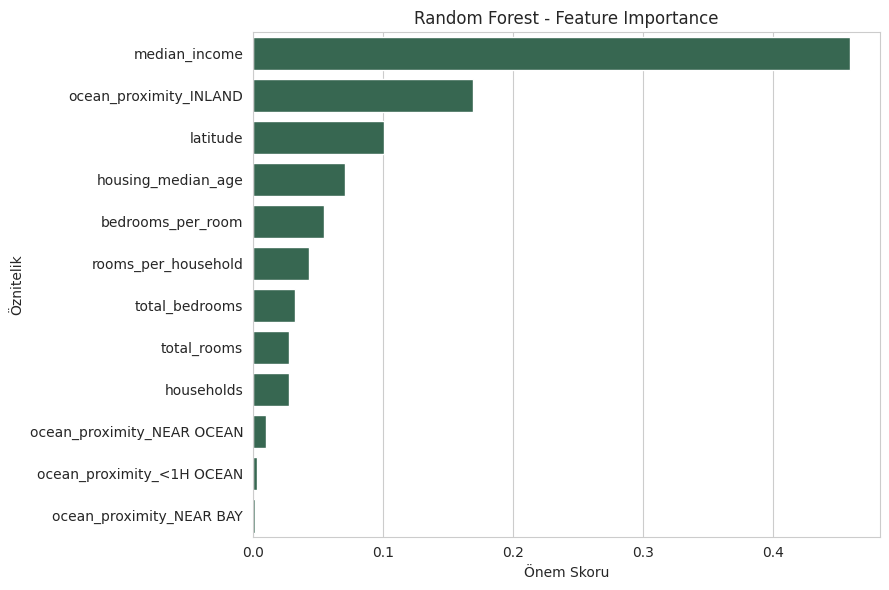

In [22]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Öznitelik": X_train_for_best.columns,
        "Önem Skoru": best_model.feature_importances_
    }).sort_values("Önem Skoru", ascending=False).reset_index(drop=True)

    print(f"{best_model_name} - Feature Importance:")
    display(importance_df)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance_df, x="Önem Skoru", y="Öznitelik", color="#2F6F52")
    plt.title(f"{best_model_name} - Feature Importance")
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, "coef_"):
    coef_df = pd.DataFrame({
        "Öznitelik": X_train_for_best.columns,
        "Katsayı": best_model.coef_
    })
    coef_df["Mutlak Katsayı"] = coef_df["Katsayı"].abs()
    coef_df = coef_df.sort_values("Mutlak Katsayı", ascending=False).reset_index(drop=True)

    print(f"{best_model_name} - Katsayılar (Coefficients):")
    display(coef_df)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=coef_df, x="Katsayı", y="Öznitelik", color="#2F6F52")
    plt.title(f"{best_model_name} - Katsayı Önemleri")
    plt.tight_layout()
    plt.show()


## 20. Sonuçların Özeti

In [23]:
print("=" * 60)
print("VALIDATION MODEL COMPARISON")
print("=" * 60)
display(val_results_df[["MAE", "RMSE", "R2"]].round(2))

print("\n" + "=" * 60)
print("FINAL MODEL")
print("=" * 60)
print(f"Best Model      : {best_model_name}")
print(f"Best Parameters : {best_params}")
print(f"Test MAE        : {test_mae:.2f}")
print(f"Test MSE        : {test_mse:.2f}")
print(f"Test RMSE       : {test_rmse:.2f}")
print(f"Test R2         : {test_r2:.4f}")


VALIDATION MODEL COMPARISON


,MAE,RMSE,R2
Model,,,
Linear Regression,47399.98,64300.31,0.58
Ridge,47391.73,64288.14,0.58
Random Forest,38418.87,54800.13,0.70



FINAL MODEL
Best Model      : Random Forest
Best Parameters : {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
Test MAE        : 38740.33
Test MSE        : 3039053211.81
Test RMSE       : 55127.61
Test R2         : 0.6895


## 21. Model Yorumu ve Sonuç Değerlendirmesi

- **Hangi model daha başarılı oldu?**  
  Validation karşılaştırmasında Random Forest Regressor, Linear Regression ve Ridge modellerine göre daha düşük MAE ve RMSE, daha yüksek R² değerleri elde etmiştir. Bu nedenle en başarılı model Random Forest olarak seçilmiştir.

- **Neden tercih edildi?**  
  Random Forest modeli validation sonuçlarında en iyi performansı göstermiştir. Ayrıca GridSearchCV sonucunda belirlenen hiperparametrelerle test veri setinde MAE = 38.740,33, RMSE = 55.127,61 ve R² = 0,6895 elde edilmiştir.

- **Hangi özellikler daha önemli?**  
  Feature importance sonuçlarına göre en önemli öznitelik `median_income` olmuştur (0,459072). Bunu `ocean_proximity_INLAND` (0,169123) ve `latitude` (0,100629) takip etmektedir. Bu sonuçlar, bölgedeki gelir düzeyinin ve konum bilgisinin ev fiyatlarının tahmininde önemli rol oynadığını göstermektedir.

- **Modelin güçlü yönleri:**  
  Random Forest, değişkenler arasındaki doğrusal olmayan ilişkileri ve öznitelikler arasındaki etkileşimleri yakalayabilmektedir. Bu nedenle doğrusal modellere kıyasla bu veri setinde daha başarılı sonuç vermiştir.

- **Modelin sınırlılıkları:**  
  Model yalnızca kullanılan veri setindeki değişkenlerden yararlanmaktadır. Konutun fiziksel durumu, yenilenme durumu veya bölgedeki bazı ekonomik ve sosyal faktörler veri setinde bulunmadığından modelin tahmin performansını sınırlayabilir. Ayrıca veri seti 1990 yılı Kaliforniya verilerine dayandığı için günümüz konut piyasasına doğrudan uygulanması uygun değildir.

- **Gerçek hayatta nerede hata yapabilir?**  
  Ekonomik koşullar, enflasyon, faiz oranları ve bölgesel gelişmeler zaman içerisinde değişebileceği için modelin güncel veriler üzerinde performansı düşebilir. Ayrıca eğitim veri setinde yeterince temsil edilmeyen mahalle veya konut türlerinde tahmin hataları daha yüksek olabilir.